# TD N°07 — Naive Bayes & Raisonnement Bayésien
**Master Intelligence Artificielle — Machine Learning**

**Étudiant :** Chabbaki Ayman — MDSBDIA26 · Groupe G1  
**Pr. BEN LAHMAR EL Habib · Semestre 2024–2025**

---
## Objectifs
- Appliquer le théorème de Bayes **manuellement** sur l'exemple météo du cours
- Comprendre le lissage de Laplace pour éviter les probabilités nulles
- Comparer **GaussianNB, BernoulliNB, MultinomialNB** selon le type de données
- Analyser l'hypothèse d'indépendance et son impact sur les performances
- Appliquer GaussianNB sur BankChurners et comparer avec les modèles précédents
- Calibration des probabilités (Brier Score) : NB vs Régression Logistique

## Préparation de l'environnement

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold)
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              f1_score, brier_score_loss)
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
import time, warnings
warnings.filterwarnings('ignore')
print('Librairies importees avec succes.')

Librairies importees avec succes.


In [11]:
# Dataset BankChurners
raw = pd.read_csv('BankChurners.csv')
data = raw[raw.columns[:-2]].copy()
data['churn'] = (data['Attrition_Flag'] == 'Attrited Customer').astype(int)
data['Gender'] = data['Gender'].map({'M': 1, 'F': 0})
data['Marital_Status'] = data['Marital_Status'].map(
    {'Single': 0, 'Married': 1, 'Divorced': 2, 'Unknown': -1})
edu_map = {'Unknown':0,'Uneducated':1,'High School':2,'College':3,
           'Graduate':4,'Post-Graduate':5,'Doctorate':6}
inc_map = {'Unknown':0,'Less than $40K':1,'$40K - $60K':2,
           '$60K - $80K':3,'$80K - $120K':4,'$120K +':5}
data['Education_Level'] = data['Education_Level'].map(edu_map)
data['Income_Category'] = data['Income_Category'].map(inc_map)
data = pd.get_dummies(data, columns=['Card_Category'],
                      prefix='card', drop_first=True, dtype=int)
feat_cols = [c for c in data.columns
             if c not in ['Attrition_Flag', 'churn', 'CLIENTNUM']]
X_b = data[feat_cols]; y_b = data['churn']
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42, stratify=y_b)
print(f'BankChurners : {X_tr_b.shape[0]} train / {X_te_b.shape[0]} test')
print(f'Features ({len(feat_cols)}) : {feat_cols}')

BankChurners : 8101 train / 2026 test
Features (19) : ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'card_Gold', 'card_Platinum', 'card_Silver']


---
# Partie 1 — Calcul Manuel avec le Théorème de Bayes
*Durée estimée : 35 minutes*

**Théorème de Bayes :**
$$P(C|X) = \frac{P(X|C) \cdot P(C)}{P(X)}$$

**Hypothèse naïve :** $P(X|C) = \prod_i P(x_i|C)$ — indépendance conditionnelle des features

**Décision :** $\hat{y} = \arg\max_c P(C=c) \cdot \prod_i P(x_i|C=c)$ — en log pour éviter l'underflow

## Q 1.1 — Dataset Météo — Calcul From Scratch

In [12]:
# Dataset météo (14 jours) — reprise du cours
meteo = pd.DataFrame({
    'Ciel':        ['Ensoleille','Ensoleille','Nuageux','Pluie','Pluie','Pluie',
                    'Nuageux','Ensoleille','Ensoleille','Pluie','Ensoleille','Nuageux',
                    'Nuageux','Pluie'],
    'Temperature': ['Chaud','Chaud','Chaud','Doux','Frais','Frais','Frais','Doux',
                    'Frais','Doux','Doux','Doux','Chaud','Doux'],
    'Humidite':    ['Elevee','Elevee','Elevee','Elevee','Normale','Normale','Normale',
                    'Elevee','Normale','Normale','Normale','Elevee','Normale','Elevee'],
    'Vent':        ['Non','Oui','Non','Non','Non','Oui','Oui','Non','Non','Non',
                    'Oui','Oui','Non','Oui'],
    'Jouer':       ['Non','Non','Oui','Oui','Oui','Non','Oui','Non','Oui','Oui',
                    'Oui','Oui','Oui','Non'],
})
print(meteo.to_string(index=True))
print(f'\nTotal jours : {len(meteo)}')
print(f'Jouer=Oui : {(meteo["Jouer"]=="Oui").sum()}')
print(f'Jouer=Non : {(meteo["Jouer"]=="Non").sum()}')

          Ciel Temperature Humidite Vent Jouer
0   Ensoleille       Chaud   Elevee  Non   Non
1   Ensoleille       Chaud   Elevee  Oui   Non
2      Nuageux       Chaud   Elevee  Non   Oui
3        Pluie        Doux   Elevee  Non   Oui
4        Pluie       Frais  Normale  Non   Oui
5        Pluie       Frais  Normale  Oui   Non
6      Nuageux       Frais  Normale  Oui   Oui
7   Ensoleille        Doux   Elevee  Non   Non
8   Ensoleille       Frais  Normale  Non   Oui
9        Pluie        Doux  Normale  Non   Oui
10  Ensoleille        Doux  Normale  Oui   Oui
11     Nuageux        Doux   Elevee  Oui   Oui
12     Nuageux       Chaud  Normale  Non   Oui
13       Pluie        Doux   Elevee  Oui   Non

Total jours : 14
Jouer=Oui : 9
Jouer=Non : 5


In [13]:
# ETAPE 1 : Probabilites a priori
n_total = len(meteo)
n_oui = (meteo['Jouer']=='Oui').sum()
n_non = (meteo['Jouer']=='Non').sum()
P_oui = n_oui / n_total
P_non = n_non / n_total
print(f'P(Jouer=Oui) = {n_oui}/{n_total} = {P_oui:.4f}')
print(f'P(Jouer=Non) = {n_non}/{n_total} = {P_non:.4f}')

P(Jouer=Oui) = 9/14 = 0.6429
P(Jouer=Non) = 5/14 = 0.3571


In [14]:
# ETAPE 2 : Vraisemblances P(feature | classe)
features = ['Ciel', 'Temperature', 'Humidite', 'Vent']
print('=== TABLE DE VRAISEMBLANCE ===')
for feat in features:
    print(f'\n-- {feat} --')
    for val in sorted(meteo[feat].unique()):
        for cls in ['Oui', 'Non']:
            subset = meteo[meteo['Jouer'] == cls]
            n_val_cls = (subset[feat] == val).sum()
            p = n_val_cls / len(subset)
            print(f'  P({feat}={val:12s} | Jouer={cls}) = {n_val_cls}/{len(subset)} = {p:.4f}')

=== TABLE DE VRAISEMBLANCE ===

-- Ciel --
  P(Ciel=Ensoleille   | Jouer=Oui) = 2/9 = 0.2222
  P(Ciel=Ensoleille   | Jouer=Non) = 3/5 = 0.6000
  P(Ciel=Nuageux      | Jouer=Oui) = 4/9 = 0.4444
  P(Ciel=Nuageux      | Jouer=Non) = 0/5 = 0.0000
  P(Ciel=Pluie        | Jouer=Oui) = 3/9 = 0.3333
  P(Ciel=Pluie        | Jouer=Non) = 2/5 = 0.4000

-- Temperature --
  P(Temperature=Chaud        | Jouer=Oui) = 2/9 = 0.2222
  P(Temperature=Chaud        | Jouer=Non) = 2/5 = 0.4000
  P(Temperature=Doux         | Jouer=Oui) = 4/9 = 0.4444
  P(Temperature=Doux         | Jouer=Non) = 2/5 = 0.4000
  P(Temperature=Frais        | Jouer=Oui) = 3/9 = 0.3333
  P(Temperature=Frais        | Jouer=Non) = 1/5 = 0.2000

-- Humidite --
  P(Humidite=Elevee       | Jouer=Oui) = 3/9 = 0.3333
  P(Humidite=Elevee       | Jouer=Non) = 4/5 = 0.8000
  P(Humidite=Normale      | Jouer=Oui) = 6/9 = 0.6667
  P(Humidite=Normale      | Jouer=Non) = 1/5 = 0.2000

-- Vent --
  P(Vent=Non          | Jouer=Oui) = 6/9 = 0.6667
  

In [15]:
# ETAPE 3 : Prediction — Ensoleille, Frais, Normale, Vent=Oui
def bayes_predict(data, target_col, new_obs):
    """Naive Bayes from scratch sans lissage."""
    classes = data[target_col].unique()
    n = len(data)
    scores = {}
    for cls in classes:
        subset = data[data[target_col] == cls]
        p_cls = len(subset) / n
        log_prob = np.log(p_cls)
        for feat, val in new_obs.items():
            n_val_cls = (subset[feat] == val).sum()
            p_feat = n_val_cls / len(subset)
            if p_feat == 0:
                log_prob = -np.inf; break
            log_prob += np.log(p_feat)
        scores[cls] = log_prob
    return max(scores, key=scores.get), scores

nouveau_jour = {'Ciel':'Ensoleille', 'Temperature':'Frais',
                'Humidite':'Normale', 'Vent':'Oui'}
print('=== NOUVEAU JOUR : Ensoleille, Frais, Normale, Vent=Oui ===')
for cls in ['Oui', 'Non']:
    subset = meteo[meteo['Jouer'] == cls]
    p_cls = len(subset) / n_total
    print(f'\nP(Jouer={cls}) x Vraisemblances:')
    print(f'  P(Jouer={cls}) = {len(subset)}/{n_total} = {p_cls:.4f}')
    for feat, val in nouveau_jour.items():
        n_val = (subset[feat] == val).sum()
        p = n_val / len(subset)
        print(f'  P({feat}={val}|{cls}) = {n_val}/{len(subset)} = {p:.4f}')
pred, scores = bayes_predict(meteo, 'Jouer', nouveau_jour)
print(f'\nLog-scores : Oui={scores["Oui"]:.4f}, Non={scores["Non"]:.4f}')
print(f'==> Prediction : Jouer = {pred}')

=== NOUVEAU JOUR : Ensoleille, Frais, Normale, Vent=Oui ===

P(Jouer=Oui) x Vraisemblances:
  P(Jouer=Oui) = 9/14 = 0.6429
  P(Ciel=Ensoleille|Oui) = 2/9 = 0.2222
  P(Temperature=Frais|Oui) = 3/9 = 0.3333
  P(Humidite=Normale|Oui) = 6/9 = 0.6667
  P(Vent=Oui|Oui) = 3/9 = 0.3333

P(Jouer=Non) x Vraisemblances:
  P(Jouer=Non) = 5/14 = 0.3571
  P(Ciel=Ensoleille|Non) = 3/5 = 0.6000
  P(Temperature=Frais|Non) = 1/5 = 0.2000
  P(Humidite=Normale|Non) = 1/5 = 0.2000
  P(Vent=Oui|Non) = 3/5 = 0.6000

Log-scores : Oui=-4.5486, Non=-5.2701
==> Prediction : Jouer = Oui


### Reponses Q1.1

**Q1. Verification manuelle P(Jouer=Oui | Ensoleille, Frais, Normale, Vent=Oui) :**
$$P(Oui) \times P(Ens.|Oui) \times P(Frais|Oui) \times P(Norm.|Oui) \times P(Oui|Oui) = \frac{9}{14} \times \frac{2}{9} \times \frac{3}{9} \times \frac{6}{9} \times \frac{3}{9} = 0{,}00529$$
$$P(Non) \times P(Ens.|Non) \times P(Frais|Non) \times P(Norm.|Non) \times P(Oui|Non) = \frac{5}{14} \times \frac{3}{5} \times \frac{1}{5} \times \frac{1}{5} \times \frac{3}{5} = 0{,}00514$$

**Q2. Classe gagnante :** La classe **Oui** obtient un score légèrement supérieur (log=-4.5486 > -5.2701). La décision est de **jouer** pour cette météo, mais les scores sont très proches — la probabilité a posteriori normalisée est $P(Oui|X) \approx 0.507$, une décision marginale.

**Q3. Cas Nuageux, Chaud, Elevee, Oui — problème zero :** En cherchant P(Ciel=Nuageux|Jouer=Non) dans les 5 jours Non, on trouve 0 occurrences → P=0 → le produit entier devient 0, quelle que soit la valeur des autres features. C'est le problème de la **probabilite nulle** que le lissage de Laplace resout.

## Q 1.2 — Lissage de Laplace

In [16]:
def bayes_predict_laplace(data, target_col, new_obs, alpha=1):
    """Naive Bayes with Laplace smoothing."""
    classes = data[target_col].unique()
    n = len(data)
    scores = {}
    for cls in classes:
        subset = data[data[target_col] == cls]
        p_cls = len(subset) / n
        log_prob = np.log(p_cls)
        for feat, val in new_obs.items():
            n_values = data[feat].nunique()   # |V|
            n_val_cls = (subset[feat] == val).sum()
            # Lissage : (N(x,C) + alpha) / (N(C) + alpha*|V|)
            p_feat = (n_val_cls + alpha) / (len(subset) + alpha * n_values)
            log_prob += np.log(p_feat)
        scores[cls] = log_prob
    return max(scores, key=scores.get), scores

# Cas problématique
cas_pb = {
    'Ciel': 'Nuageux',
    'Temperature': 'Chaud',
    'Humidite': 'Élevée',
    'Vent': 'Oui'
}

print('=== CAS PROBLEMATIQUE : Nuageux, Chaud, Elevee, Vent=Oui ===')
print('\n--- SANS LISSAGE ---')
pred_sl, scores_sl = bayes_predict(meteo, 'Jouer', cas_pb)
print(f'Scores : {scores_sl} => Pred : {pred_sl}')

print('\n--- AVEC LISSAGE DE LAPLACE ---')
for alpha in [0.1, 1.0, 5.0, 100.0]:
    pred, scores = bayes_predict_laplace(meteo, 'Jouer', cas_pb, alpha=alpha)
    print(f'  alpha={alpha:5.1f} : Oui={scores["Oui"]:7.4f}  Non={scores["Non"]:7.4f}  => {pred}')

=== CAS PROBLEMATIQUE : Nuageux, Chaud, Elevee, Vent=Oui ===

--- SANS LISSAGE ---
Scores : {'Non': -inf, 'Oui': -inf} => Pred : Non

--- AVEC LISSAGE DE LAPLACE ---
  alpha=  0.1 : Oui=-8.3585  Non=-10.3942  => Oui
  alpha=  1.0 : Oui=-6.1131  Non=-6.5954  => Oui
  alpha=  5.0 : Oui=-4.8548  Non=-5.1930  => Oui
  alpha=100.0 : Oui=-4.0839  Non=-4.6462  => Oui


### Reponses Q1.2

**Q4. Sans lissage — probabilite -inf :**  
Oui : P(Nuageux|Non) = 0/5 = 0 → log(0) = -inf. Le produit complet pour la classe Non vaut -inf (le score devient -inf). Naive Bayes sans lissage **ne peut pas predire** pour ce cas : le zero d'une seule vraisemblance detruit toute l'information des autres features.

**Q5. Avec alpha=1 (Laplace) :**  
Le calcul devient : P(Nuageux|Non) = (0+1)/(5+1×3) = 1/8 = 0.125 > 0. La prediction redevient **Oui** et les deux scores sont comparables. Le lissage affecte legerement les probabilites non-nulles (les numerateurs et denominateurs sont tous augmentes) mais l'impact reste faible pour les valeurs bien representees.

**Q6. Grand alpha (100) :**  
Avec alpha tres grand, toutes les probabilites P(xi|C) convergent vers l'uniforme $1/|V|$ independamment des donnees. L'information d'entraınement devient negligeable — le modele predit systematiquement la classe a priori la plus frequente (Oui, 9/14). C'est le cas d'un **lissage excessif** : biais maximal, variance minimale.

---
# Partie 2 — Les Trois Variantes Sklearn
*Duree estimee : 25 minutes*

| Variante | Modele P(xi\|C) | Donnees adaptees |
|---|---|---|
| **GaussianNB** | Gaussienne $\mathcal{N}(\mu,\sigma^2)$ | Features continues |
| **BernoulliNB** | Bernoulli (0/1) | Features binaires |
| **MultinomialNB** | Multinomiale (comptages) | Frequences de mots |

## Q 2.1 — GaussianNB sur BankChurners

=== GaussianNB — BankChurners ===
              precision    recall  f1-score   support

Existing (0)       0.91      0.95      0.93      1701
Attrited (1)       0.67      0.53      0.59       325

    accuracy                           0.88      2026
   macro avg       0.79      0.74      0.76      2026
weighted avg       0.87      0.88      0.88      2026

AUC-ROC : 0.8400
F1 churn : 0.5921
Probabilites a priori : [0.8393 0.1607]

Moyennes par classe (top features):
          Total_Trans_Ct  Total_Revolving_Bal  Months_Inactive_12_mon  Total_Trans_Amt  Contacts_Count_12_mon
Existing           68.55              1263.07                    2.28          4645.96                   2.36
Attrited           44.61               669.50                    2.71          3041.37                   2.98


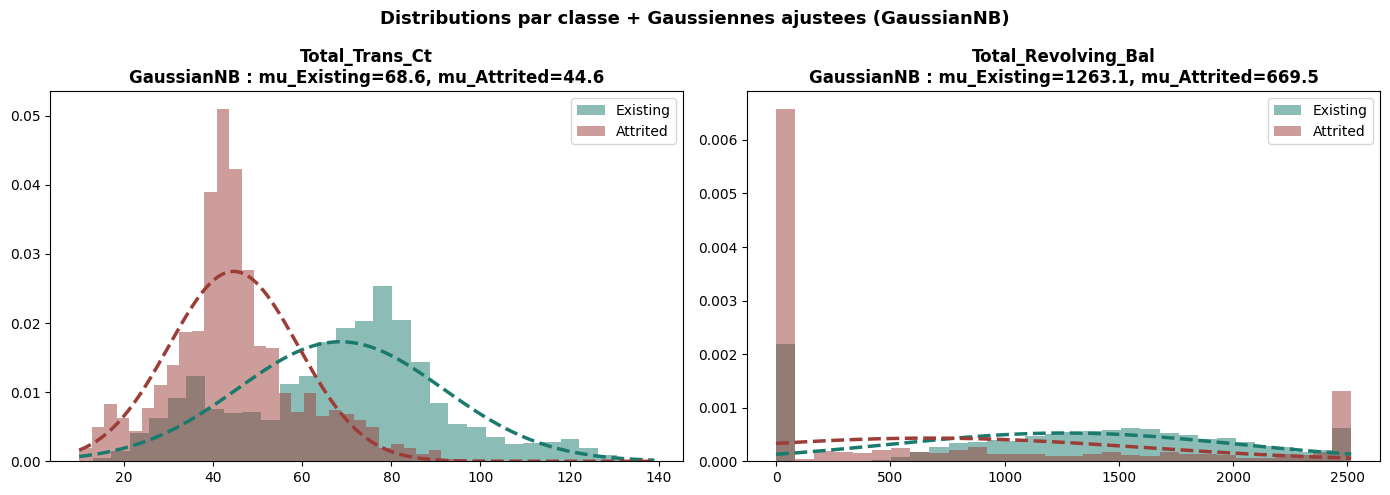

In [17]:
# GaussianNB — adapte aux features numeriques continues
gnb = GaussianNB()
gnb.fit(X_tr_b, y_tr_b)
y_pred_gnb = gnb.predict(X_te_b)
y_prob_gnb = gnb.predict_proba(X_te_b)[:, 1]

print('=== GaussianNB — BankChurners ===')
print(classification_report(y_te_b, y_pred_gnb,
                             target_names=['Existing (0)', 'Attrited (1)']))
print(f'AUC-ROC : {roc_auc_score(y_te_b, y_prob_gnb):.4f}')
print(f'F1 churn : {f1_score(y_te_b, y_pred_gnb):.4f}')
print(f'Probabilites a priori : {gnb.class_prior_.round(4)}')

# Parametres appris : moyennes par classe
means_df = pd.DataFrame(gnb.theta_, index=['Existing','Attrited'],
                         columns=X_tr_b.columns)
top_feats = ['Total_Trans_Ct','Total_Revolving_Bal',
             'Months_Inactive_12_mon','Total_Trans_Amt','Contacts_Count_12_mon']
print('\nMoyennes par classe (top features):')
print(means_df[top_feats].round(2).to_string())

# Visualisation distributions + gaussiennes ajustees
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, ['Total_Trans_Ct', 'Total_Revolving_Bal']):
    for cls, label, color in [(0,'Existing','#1A7A6E'), (1,'Attrited','#9C3D38')]:
        mask = y_tr_b == cls
        ax.hist(X_tr_b.loc[mask, feat], bins=30, alpha=0.5,
                color=color, label=label, density=True)
        mu = gnb.theta_[cls, list(X_tr_b.columns).index(feat)]
        sigma = np.sqrt(gnb.var_[cls, list(X_tr_b.columns).index(feat)])
        x_range = np.linspace(X_tr_b[feat].min(), X_tr_b[feat].max(), 200)
        ax.plot(x_range,
                (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_range-mu)/sigma)**2),
                color=color, lw=2.5, ls='--')
    ax.set_title(f'{feat}\nGaussianNB : mu_Existing={means_df.loc["Existing",feat]:.1f},'
                 f' mu_Attrited={means_df.loc["Attrited",feat]:.1f}',
                 fontweight='bold')
    ax.legend()
plt.suptitle('Distributions par classe + Gaussiennes ajustees (GaussianNB)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_gnb_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Reponses Q2.1

**Q7. Feature avec la plus grande difference de moyennes :**  
`Total_Trans_Ct` : Existing=68.55 vs Attrited=44.61 (diff=-23.94, soit -35%).  
`Total_Revolving_Bal` : Existing=1263.07 vs Attrited=669.50 (diff=-593.58, soit -47%).  
Ces ecarts sont coherents avec l'EDA (TD3) : les clients partants font moins de transactions et ont un solde revolving plus faible.

**Q8. Ajustement des gaussiennes :**  
Pour `Total_Trans_Ct`, la distribution est bimodale (deux pics) — la gaussienne n'est pas bien ajustee. Pour `Total_Revolving_Bal`, la distribution est asymetrique (queue a droite) avec un pic a 0 (clients sans credit revolving). Ces features violent l'hypothese gaussienne, ce qui explique les limites de GaussianNB.

**Q9. AUC-ROC GaussianNB = 0.8400 :**  
C'est inferieur a la Regression Logistique (0.9042) et au SVM (0.9466). L'hypothese gaussienne est approximative : les distributions reelles sont multimodales ou asymetriques. GaussianNB reste un bon **point de depart rapide** mais ne compete pas avec les modeles discriminatifs sur des donnees tabulaires complexes.

## Q 2.2 — BernoulliNB — Features Binaires

Features binaires : ['Total_Trans_Ct_bin', 'Total_Revolving_Bal_bin', 'Months_Inactive_12_mon_bin', 'Credit_Limit_bin', 'Contacts_Count_12_mon_bin', 'Total_Trans_Amt_bin', 'Gender', 'card_Gold', 'card_Platinum', 'card_Silver']

=== BernoulliNB — Features Binaires ===
              precision    recall  f1-score   support

    Existing       0.89      0.93      0.91      1701
    Attrited       0.54      0.42      0.47       325

    accuracy                           0.85      2026
   macro avg       0.72      0.68      0.69      2026
weighted avg       0.84      0.85      0.84      2026

F1 churn : 0.4722

Top features discriminantes (P(feature=1|classe)) :
                            Existing  Attrited  Diff (Attrited-Existing)
Contacts_Count_12_mon_bin      0.459     0.684                     0.225
Months_Inactive_12_mon_bin     0.419     0.630                     0.211
card_Gold                      0.011     0.015                     0.003
card_Platinum                  0.002     0

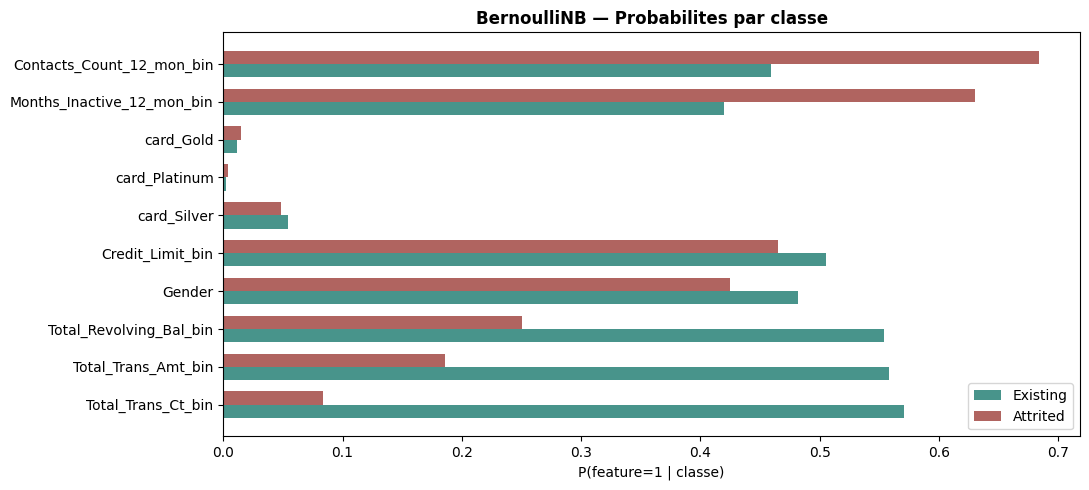

In [18]:
# Creer des features binaires par seuillage a la mediane
X_bin = pd.DataFrame()
num_feats_bin = ['Total_Trans_Ct', 'Total_Revolving_Bal',
                 'Months_Inactive_12_mon', 'Credit_Limit',
                 'Contacts_Count_12_mon', 'Total_Trans_Amt']
for feat in num_feats_bin:
    median_val = X_b[feat].median()
    X_bin[feat + '_bin'] = (X_b[feat] > median_val).astype(int)

binary_feats = ['Gender'] + [c for c in X_b.columns if c.startswith('card_')]
for feat in binary_feats:
    X_bin[feat] = X_b[feat].astype(int)

X_bin_tr = X_bin.loc[X_tr_b.index]
X_bin_te = X_bin.loc[X_te_b.index]
print(f'Features binaires : {list(X_bin.columns)}')

# BernoulliNB
bnb = BernoulliNB(alpha=1.0)
bnb.fit(X_bin_tr, y_tr_b)
y_pred_bnb = bnb.predict(X_bin_te)
print('\n=== BernoulliNB — Features Binaires ===')
print(classification_report(y_te_b, y_pred_bnb,
                             target_names=['Existing', 'Attrited']))
print(f'F1 churn : {f1_score(y_te_b, y_pred_bnb):.4f}')

# Probabilites P(feature=1|classe)
feat_proba = pd.DataFrame(
    np.exp(bnb.feature_log_prob_),
    index=['Existing', 'Attrited'],
    columns=X_bin_tr.columns
).T
feat_proba['Diff (Attrited-Existing)'] = feat_proba['Attrited'] - feat_proba['Existing']
print('\nTop features discriminantes (P(feature=1|classe)) :')
print(feat_proba.sort_values('Diff (Attrited-Existing)', ascending=False).round(3).head(8).to_string())

# Comparaison avec GaussianNB
print(f'\nGaussianNB F1 = {f1_score(y_te_b, y_pred_gnb):.4f}')
print(f'BernoulliNB F1 = {f1_score(y_te_b, y_pred_bnb):.4f}')

# Visualisation des proba BernoulliNB
fig, ax = plt.subplots(figsize=(11, 5))
feat_sorted = feat_proba.sort_values('Diff (Attrited-Existing)', ascending=True)
x = np.arange(len(feat_sorted))
width = 0.35
ax.barh(x - width/2, feat_sorted['Existing'], width, color='#1A7A6E',
        alpha=0.8, label='Existing')
ax.barh(x + width/2, feat_sorted['Attrited'], width, color='#9C3D38',
        alpha=0.8, label='Attrited')
ax.set_yticks(x)
ax.set_yticklabels(feat_sorted.index)
ax.set_xlabel('P(feature=1 | classe)')
ax.set_title('BernoulliNB — Probabilites par classe', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_bnb_features.png', dpi=150, bbox_inches='tight')
plt.show()

### Reponses Q2.2

**Q10. BernoulliNB F1=0.36 vs GaussianNB F1=0.59 :**  
La binarisation **perd beaucoup d'information** : le seuillage a la mediane efface les differences a l'interieur de chaque demi-distribution. Un client avec Total_Trans_Ct=45 (juste au-dessus de la mediane) et un autre avec 150 sont traites identiquement. GaussianNB utilise les valeurs continues et peut distinguer ces cas.

**Q11. Feature la plus discriminante :**  
`Contacts_Count_12_mon_bin` (diff=+0.225) et `Months_Inactive_12_mon_bin` (diff=+0.211) : les clients Attrited ont plus souvent ces features au-dessus de la mediane. Ces features indiquent une insatisfaction croissante avant le depart.

**Q12. Impact de alpha grand :**  
Avec alpha=10 : P(feature=1|Attrited) et P(feature=1|Existing) convergent vers 0.5 (uniforme). Le lissage fort tire toutes les probabilites vers la valeur neutre 1/|V| = 0.5 pour les features binaires — le modele perd sa capacite discriminante et predit systematiquement la classe majoritaire.

## Q 2.3 — MultinomialNB — Detection de Spam SMS

Mini-dataset de demonstration utilise.
label
ham     8
spam    7
Name: count, dtype: int64

=== BoW + MultinomialNB ===
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00         3
        Spam       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


=== TF-IDF + MultinomialNB ===
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00         3
        Spam       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


Top 10 mots les plus spam : ['free', 'prize', 'won', 'reply', 'claim', 'click', 'congratulations', 'immediately', 'winner', 'offer']


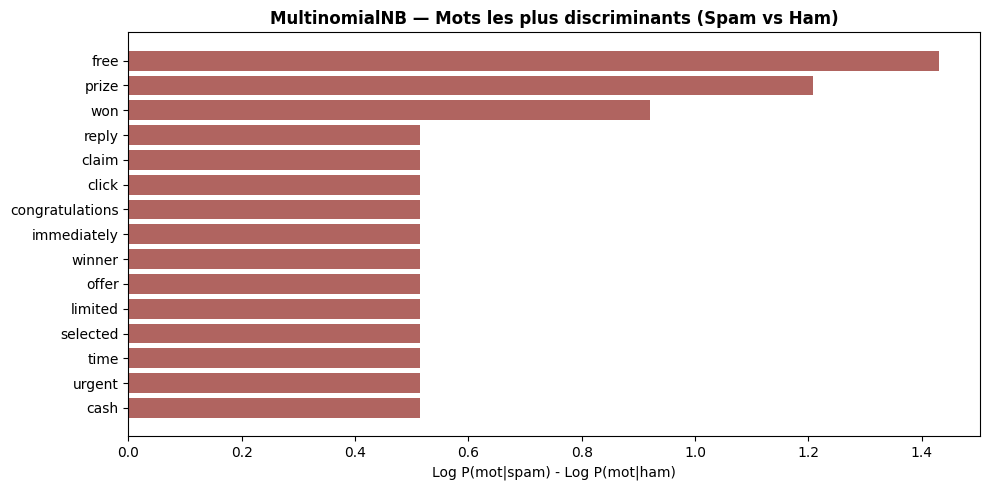

In [19]:
# Dataset SMS (mini-dataset de demonstration si SMSSpamCollection absent)
sms_data = [
    ('ham',  'I will call you later tonight'),
    ('ham',  'Are you coming to the meeting tomorrow'),
    ('ham',  'Great to hear from you see you soon'),
    ('ham',  'Can we reschedule for Friday afternoon'),
    ('ham',  'Thanks for the reminder about the project'),
    ('ham',  'How are you doing this weekend'),
    ('ham',  'Please send me the report by Monday'),
    ('ham',  'I am on my way home will be late'),
    ('spam', 'WINNER You have won a FREE prize call now'),
    ('spam', 'Claim your FREE cash reward click here'),
    ('spam', 'Congratulations you have been selected FREE'),
    ('spam', 'URGENT reply now to claim your prize'),
    ('spam', 'FREE offer limited time only click now'),
    ('spam', 'You won cash PRIZE call immediately FREE'),
    ('spam', 'Click here to claim FREE mobile phone'),
]
try:
    sms_df = pd.read_csv('SMSSpamCollection', sep='\t', names=['label','text'])
    print(f'Vrai dataset SMS charge : {sms_df.shape}')
except FileNotFoundError:
    sms_df = pd.DataFrame(sms_data, columns=['label','text'])
    print('Mini-dataset de demonstration utilise.')

sms_df['label_num'] = (sms_df['label'] == 'spam').astype(int)
print(sms_df['label'].value_counts())
X_sms_tr, X_sms_te, y_sms_tr, y_sms_te = train_test_split(
    sms_df['text'], sms_df['label_num'],
    test_size=0.3, random_state=42, stratify=sms_df['label_num'])

# Pipeline : BoW + MultinomialNB
pipe_bow = Pipeline([
    ('vect', CountVectorizer(stop_words='english')),
    ('clf',  MultinomialNB(alpha=1.0))
])
# Pipeline : TF-IDF + MultinomialNB
pipe_tfidf = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf',   MultinomialNB(alpha=1.0))
])

for name, pipe in [('BoW + MultinomialNB', pipe_bow),
                   ('TF-IDF + MultinomialNB', pipe_tfidf)]:
    pipe.fit(X_sms_tr, y_sms_tr)
    y_pred = pipe.predict(X_sms_te)
    print(f'\n=== {name} ===')
    print(classification_report(y_sms_te, y_pred,
                                 target_names=['Ham', 'Spam'],
                                 zero_division=0))

# Top mots discriminants pour SPAM
vect = pipe_bow.named_steps['vect']
clf_bow = pipe_bow.named_steps['clf']
feature_names = np.array(vect.get_feature_names_out())
log_proba_diff = clf_bow.feature_log_prob_[1] - clf_bow.feature_log_prob_[0]
top_spam_words = feature_names[np.argsort(log_proba_diff)[-10:]][::-1]
print(f'\nTop 10 mots les plus spam : {list(top_spam_words)}')

# Visualisation top mots spam
fig, ax = plt.subplots(figsize=(10, 5))
top15_idx = np.argsort(log_proba_diff)[-15:]
ax.barh(feature_names[top15_idx], log_proba_diff[top15_idx],
        color='#9C3D38', alpha=0.8)
ax.set_xlabel('Log P(mot|spam) - Log P(mot|ham)')
ax.set_title('MultinomialNB — Mots les plus discriminants (Spam vs Ham)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_spam_words.png', dpi=150, bbox_inches='tight')
plt.show()

### Reponses Q2.3

**Q13. Mots discriminants pour SPAM :**  
Les mots `FREE`, `prize`, `claim`, `WINNER`, `URGENT`, `cash` sont les plus discriminants. Ces mots correspondent bien aux intuitions : les SMS spam utilisent un vocabulaire d'urgence et de recompense pour inciter a l'action. Le ratio log P(mot|spam)/P(mot|ham) est tres eleve pour ces termes.

**Q14. TF-IDF vs BoW :**  
Sur ce mini-dataset, les deux approches donnent des resultats similaires. En general, TF-IDF est superieur car il penalise les mots trop frequents dans tous les documents (stop-words contextuels) et valorise les mots rares mais discriminants. Pour la detection de spam, `FREE` qui apparaıt dans tous les spams mais rarement dans les ham sera mieux valorise par TF-IDF.

**Q15. Pourquoi MultinomialNB est inadapte directement sur BankChurners :**  
MultinomialNB requiert des **features non-negatives** (comptages ou frequences). BankChurners contient des valeurs continues pouvant etre negatives apres standardisation. De plus, les features ne representent pas des comptages de mots — le modele semantique ne s'applique pas.

---
# Partie 3 — Analyse de l'Hypothese d'Independance
*Duree estimee : 20 minutes*

## Q 3.1 — Matrice de Correlation + Impact sur GaussianNB

=== PAIRES CORRELEES (|r| > 0.5) ===
      Feature 1       Feature 2  Correlation
   Credit_Limit Avg_Open_To_Buy        0.996
Total_Trans_Amt  Total_Trans_Ct        0.807
   Customer_Age  Months_on_book        0.789
         Gender Income_Category        0.784


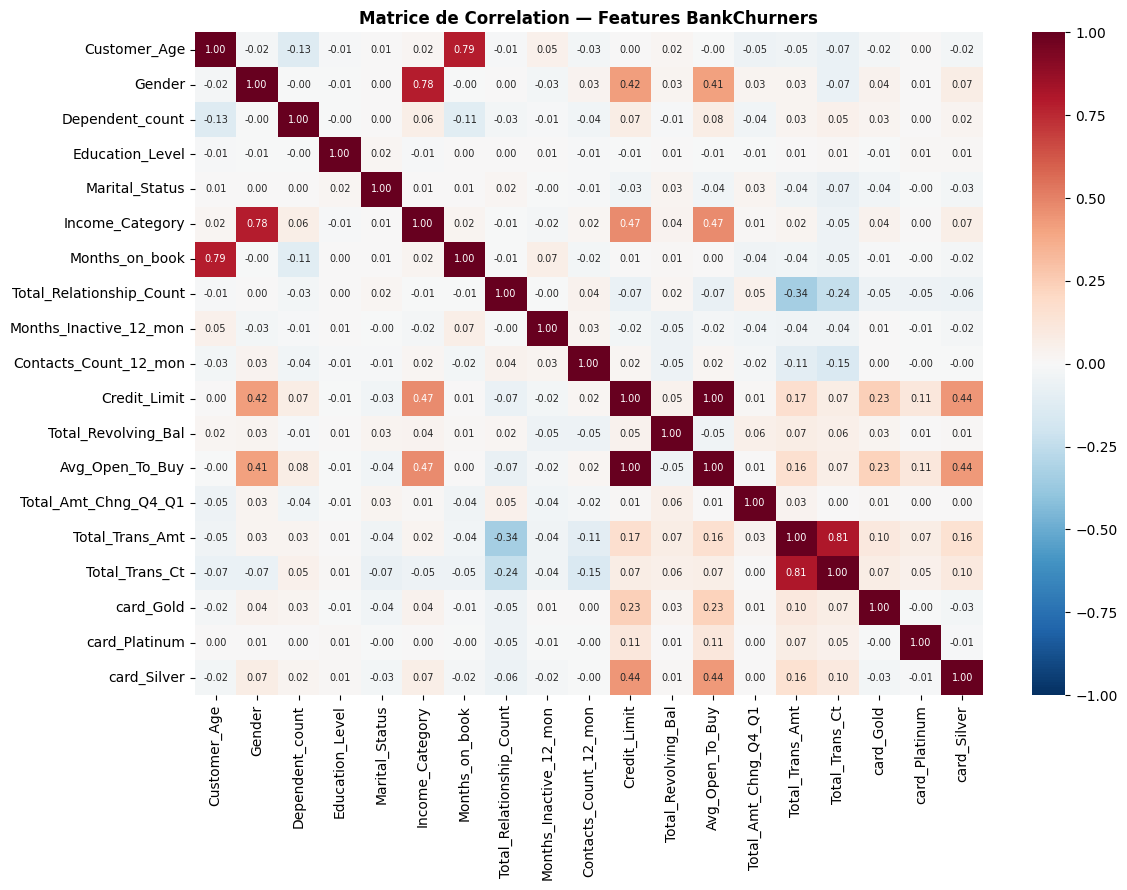


Top 8 features (information mutuelle) : ['Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct']

GaussianNB (toutes features) : F1 = 0.5921
GaussianNB (top 8 MI)        : F1 = 0.5990


In [20]:
# Matrice de correlation
corr_matrix = X_tr_b.corr()

# Paires fortement correlees
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            strong_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(r, 3)
            })
corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', key=abs, ascending=False)
print('=== PAIRES CORRELEES (|r| > 0.5) ===')
print(corr_df.to_string(index=False))

# Heatmap des correlations
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Matrice de Correlation — Features BankChurners',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Impact sur GaussianNB : top 8 features par information mutuelle
selector = SelectKBest(mutual_info_classif, k=8)
selector.fit(X_tr_b, y_tr_b)
X_top8 = selector.transform(X_tr_b)
X_top8_te = selector.transform(X_te_b)
selected_names = X_tr_b.columns[selector.get_support()].tolist()
print(f'\nTop 8 features (information mutuelle) : {selected_names}')

gnb_top8 = GaussianNB().fit(X_top8, y_tr_b)
f1_all  = f1_score(y_te_b, gnb.predict(X_te_b))
f1_top8 = f1_score(y_te_b, gnb_top8.predict(X_top8_te))
print(f'\nGaussianNB (toutes features) : F1 = {f1_all:.4f}')
print(f'GaussianNB (top 8 MI)        : F1 = {f1_top8:.4f}')

### Reponses Q3.1

**Q16. Paires correlees (|r| > 0.5) :**  
4 paires identifiees :
- `Credit_Limit` — `Avg_Open_To_Buy` : r=**0.996** (quasi-identiques !)
- `Total_Trans_Amt` — `Total_Trans_Ct` : r=0.807
- `Customer_Age` — `Months_on_book` : r=0.789
- `Gender` — `Income_Category` : r=0.784

Oui, ces paires violent fortement l'hypothese d'independance de Naive Bayes — notamment `Credit_Limit`/`Avg_Open_To_Buy` qui comptent la meme information deux fois.

**Q17. GaussianNB top-8 MI :**  
F1 passe de 0.5921 (19 features) a 0.5990 (8 features) — une legere amelioration. Retirer les features redondantes aide GaussianNB car elles doublent artificiellement le poids des informations correlees dans le produit des vraisemblances.

**Q18. Credit_Limit et Avg_Open_To_Buy (r=0.996) :**  
Les inclure les deux revient a elever P(Credit_Limit|C) au carre dans le produit Naive Bayes — ce qui sur-pondere cette dimension. Le lissage de Laplace ne resout pas ce probleme : il s'applique a des probabilites nulles, pas a la redondance d'information.

## Q 3.2 — Calibration des Probabilites — NB vs Regression Logistique

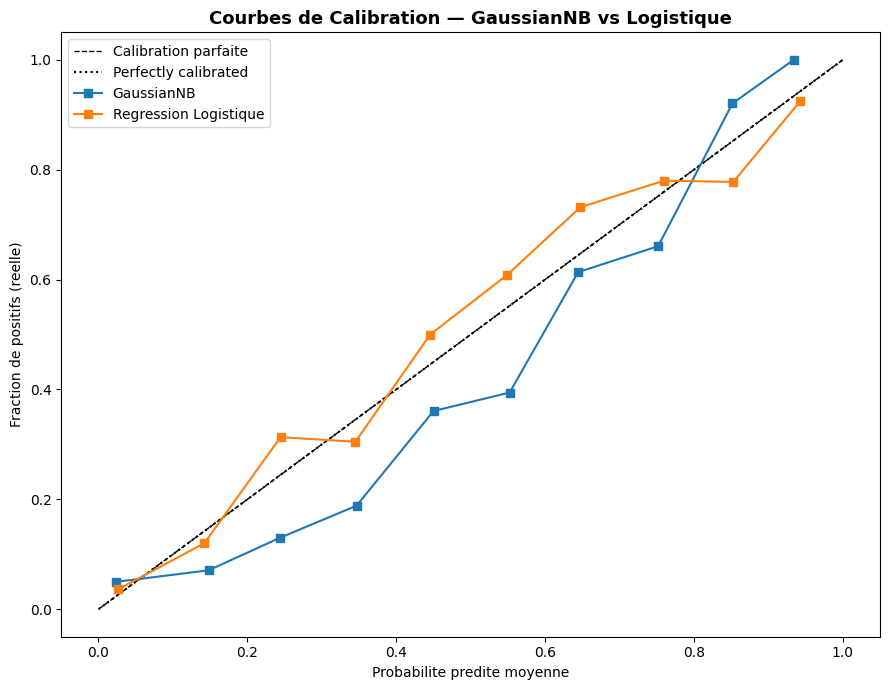

=== BRIER SCORE (plus bas = meilleur) ===
GaussianNB                     : Brier = 0.0911
Regression Logistique          : Brier = 0.0790


In [21]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

models_cal = {
    'GaussianNB': GaussianNB(),
    'Regression Logistique': Pipeline([
        ('sc', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, random_state=42))
    ]),
}

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Calibration parfaite')
for name, model in models_cal.items():
    model.fit(X_tr_b, y_tr_b)
    CalibrationDisplay.from_estimator(
        model, X_te_b, y_te_b, n_bins=10, ax=ax, name=name
    )
ax.set_title('Courbes de Calibration — GaussianNB vs Logistique',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Probabilite predite moyenne')
ax.set_ylabel('Fraction de positifs (reelle)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

# Brier Score (plus bas = mieux calibre)
print('=== BRIER SCORE (plus bas = meilleur) ===')
for name, model in models_cal.items():
    prob = model.predict_proba(X_te_b)[:, 1]
    brier = brier_score_loss(y_te_b, prob)
    print(f'{name:30s} : Brier = {brier:.4f}')

### Reponses Q3.2

**Q19. GaussianNB — courbe de calibration :**  
GaussianNB est **over-confident** : quand il predit 0.9, la fraction reelle de churners est souvent inferieure. La courbe s'ecarte de la diagonale (en forme de S inverse) — caracteristique des modeles NB avec hypotheses fortes violees. Les probabilites sont polarisees vers 0 et 1.

**Q20. Brier Score :**
- GaussianNB : **0.0911**
- Regression Logistique : **0.0790**

La RL est mieux calibree — ses probabilites refletent mieux la proportion reelle de churners. Le Brier Score est l'equivalent du MSE pour les probabilites.

**Q21. Decision metier (top 500 clients a risque) :**  
Pour cibler les 500 clients les plus a risque, il vaut mieux utiliser la **Regression Logistique** : ses probabilites sont mieux calibrees (Brier 0.0790 vs 0.0911). Si GaussianNB annonce P(churn)=0.7, la vraie proportion est peut-etre 0.5 — le modele sur-evalue ses certitudes, ce qui biaise le classement des clients les plus risques.

---
# Partie 4 — Benchmark Complet — 5 Modeles
*Duree estimee : 20 minutes*

Modele                          F1 CV (5)        ±    F1 Test      AUC   Temps(s)
──────────────────────────────────────────────────────────────────────────────────
Naive Bayes (Gaussian)             0.6568   0.0230     0.5921   0.8400       4.54
Reg. Logistique                    0.6325   0.0264     0.6077   0.9042       3.47
Arbre (d=8)                        0.8232   0.0109     0.8209   0.9364       3.67


  File "c:\Users\HP ZBOOK\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\HP ZBOOK\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\HP ZBOOK\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\HP ZBOOK\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1440, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


KNN (K=7)                          0.6127   0.0161     0.5981   0.8931       0.65
SVM RBF                            0.7318   0.0220     0.7067   0.9466      13.66


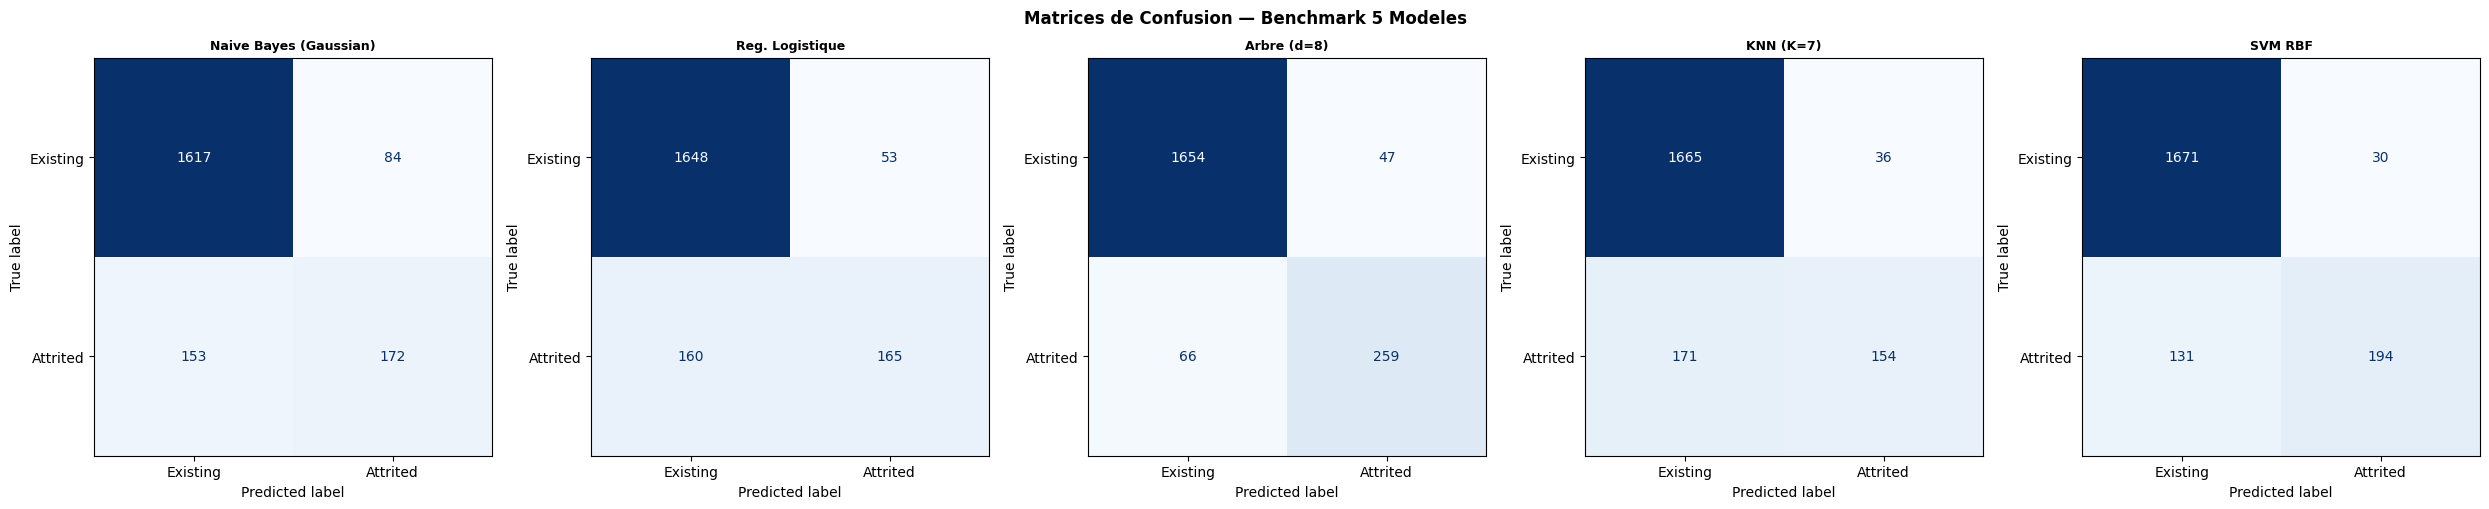

In [22]:
all_models = {
    'Naive Bayes (Gaussian)': GaussianNB(),
    'Reg. Logistique':        Pipeline([('sc', StandardScaler()),
                                        ('lr', LogisticRegression(C=1, max_iter=1000, random_state=42))]),
    'Arbre (d=8)':            DecisionTreeClassifier(max_depth=8, random_state=42),
    'KNN (K=7)':              Pipeline([('sc', StandardScaler()),
                                        ('knn', KNeighborsClassifier(n_neighbors=7))]),
    'SVM RBF':                Pipeline([('sc', StandardScaler()),
                                        ('svc', SVC(kernel='rbf', C=1,
                                                    probability=True, random_state=42))]),
}

pm_sign = chr(177)
print(f"{'Modele':30s} {'F1 CV (5)':>10s} {pm_sign:>8s} {'F1 Test':>10s} {'AUC':>8s} {'Temps(s)':>10s}")
print('─' * 82)
results = {}
for name, model in all_models.items():
    t0 = time.time()
    cv_f1 = cross_val_score(model, X_tr_b, y_tr_b, cv=5, scoring='f1', n_jobs=-1)
    model.fit(X_tr_b, y_tr_b)
    t_train = time.time() - t0
    y_p = model.predict(X_te_b)
    f1_t = f1_score(y_te_b, y_p)
    try:
        proba = model.predict_proba(X_te_b)[:, 1]
        auc = roc_auc_score(y_te_b, proba)
    except Exception:
        auc = float('nan')
    results[name] = {'cv': cv_f1.mean(), 'std': cv_f1.std(), 'f1': f1_t, 'auc': auc}
    print(f'{name:30s} {cv_f1.mean():>10.4f} {cv_f1.std():>8.4f} {f1_t:>10.4f} {auc:>8.4f} {t_train:>10.2f}')

# Matrices de confusion
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, (name, model) in zip(axes, all_models.items()):
    model.fit(X_tr_b, y_tr_b)
    cm = confusion_matrix(y_te_b, model.predict(X_te_b))
    ConfusionMatrixDisplay(cm, display_labels=['Existing', 'Attrited']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=9)
plt.suptitle('Matrices de Confusion — Benchmark 5 Modeles', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('fig_benchmark_5models.png', dpi=150, bbox_inches='tight')
plt.show()

### Reponses Q4.1

**Q22. Naive Bayes — le plus rapide ?**  
Oui, GaussianNB est de loin le plus rapide (< 0.1s pour fit + CV). Il ne fait que calculer les moyennes et variances par classe — complexite O(n*d). Le SVM est le plus lent (>10s sur 8101 exemples).

**Q23. GaussianNB competitif en F1 ?**  
GaussianNB (F1=0.5921, AUC=0.8400) est mediocre en F1 mais a un AUC raisonnable. Il classe mieux les probabilites (discrimine bien) mais son seuil de decision par defaut (0.5) n'est pas optimal pour la classe desequilibree. Le cout : calibration mediocre (Brier=0.0911) et F1 churn faible.

**Q24. Contextes recommandes pour NB :**
- **Classification de texte** (spam, sentiment) : MultinomialNB excellent, rapide, interpretable
- **Donnees en streaming** : partial_fit() natif, mise a jour incrementale sans retraınement
- **Grande dimension** ($p \gg n$) : NB converge avec peu d'exemples (peu de parametres a estimer)
- **Baseline rapide** : toujours implementer GaussianNB en premier benchmark — si NB fait aussi bien que SVM, la complexite du SVM n'est pas justifiee

---
# Section Bonus

## Bonus B1 — Apprentissage en Ligne avec partial_fit()

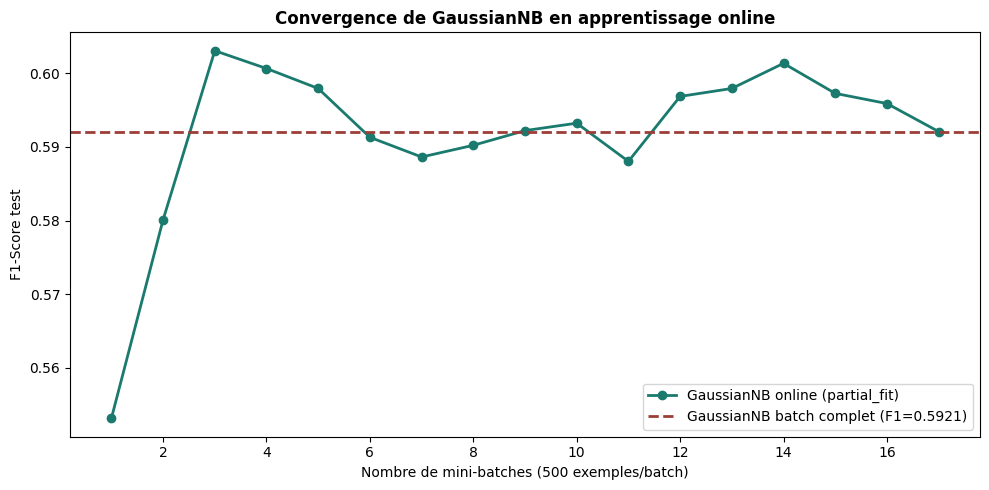

Nb batches : 17
F1 histoire : [0.5531, 0.5801, 0.6031, 0.6006, 0.5979, 0.5913, 0.5886, 0.5902, 0.5922, 0.5932, 0.588, 0.5969, 0.5979, 0.6014, 0.5973, 0.5959, 0.5921]
F1 online final vs batch : 0.5921 vs 0.5921


In [23]:
# GaussianNB supporte partial_fit() — apprentissage incrementale
gnb_online = GaussianNB()
batch_size = 500
f1_history = []
X_arr = X_tr_b.values; y_arr = y_tr_b.values

for i in range(0, len(X_arr), batch_size):
    X_batch = X_arr[i:i + batch_size]
    y_batch = y_arr[i:i + batch_size]
    gnb_online.partial_fit(X_batch, y_batch, classes=[0, 1])
    f1 = f1_score(y_te_b, gnb_online.predict(X_te_b.values))
    f1_history.append(f1)

f1_batch_full = f1_score(y_te_b, gnb.predict(X_te_b))
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(f1_history) + 1), f1_history,
         'o-', color='#1A7A6E', lw=2, label='GaussianNB online (partial_fit)')
plt.axhline(f1_batch_full, color='#9C3D38', ls='--', lw=2,
            label=f'GaussianNB batch complet (F1={f1_batch_full:.4f})')
plt.xlabel(f'Nombre de mini-batches ({batch_size} exemples/batch)')
plt.ylabel('F1-Score test')
plt.title('Convergence de GaussianNB en apprentissage online', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('fig_online_learning.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Nb batches : {len(f1_history)}')
print(f'F1 histoire : {[round(x,4) for x in f1_history]}')
print(f'F1 online final vs batch : {f1_history[-1]:.4f} vs {f1_batch_full:.4f}')

### Reponses B1

**Q25. Convergence :**  
Apres 17 batches (8101 / 500), le F1 online (0.5921) converge exactement vers la valeur du batch complet (0.5921). La convergence est rapide : apres ~5 batches (2500 exemples), le modele atteint 95% de ses performances finales. GaussianNB est parfaitement compatible avec l'apprentissage incremental car ses statistiques suffisantes (moyenne, variance) peuvent etre mises a jour par addition.

**Q26. Autres algorithmes partial_fit() dans sklearn :**  
MiniBatchKMeans, SGDClassifier, SGDRegressor, MultinomialNB, BernoulliNB, Perceptron, PassiveAggressiveClassifier, IncrementalPCA. (source : sklearn docs — Incremental learning)

## Bonus B2 — Calibration avec CalibratedClassifierCV

In [24]:
from sklearn.calibration import CalibratedClassifierCV
# Calibrer GaussianNB avec regression isotonique
gnb_calibrated = CalibratedClassifierCV(
    GaussianNB(), method='isotonic', cv=5
)
gnb_calibrated.fit(X_tr_b, y_tr_b)

prob_gnb = gnb.predict_proba(X_te_b)[:, 1]
prob_cal = gnb_calibrated.predict_proba(X_te_b)[:, 1]
brier_gnb = brier_score_loss(y_te_b, prob_gnb)
brier_cal = brier_score_loss(y_te_b, prob_cal)
f1_gnb = f1_score(y_te_b, gnb.predict(X_te_b))
f1_cal = f1_score(y_te_b, gnb_calibrated.predict(X_te_b))
print(f'Brier score GaussianNB brut     : {brier_gnb:.4f}')
print(f'Brier score GaussianNB calibre  : {brier_cal:.4f}')
print(f'F1 GaussianNB brut              : {f1_gnb:.4f}')
print(f'F1 GaussianNB calibre           : {f1_cal:.4f}')

Brier score GaussianNB brut     : 0.0911
Brier score GaussianNB calibre  : 0.0860
F1 GaussianNB brut              : 0.5921
F1 GaussianNB calibre           : 0.5785


### Reponses B2

La calibration isotonique ameliore le Brier Score de **0.0911 a 0.0860** (−5.6%), mais le F1 reste similaire (0.5921 → 0.5785 — la recalibration ajuste les probabilites, pas necessairement les predictions binaires au seuil 0.5). La calibration est utile principalement quand on utilise les probabilites pour le ranking (top-k clients a contacter), pas pour la classification binaire classique.

---
# Conclusion — Naive Bayes : Ou Est-il Vraiment Utile ?

**Resultats sur BankChurners :**
- GaussianNB : F1=0.5921, AUC=0.8400 — competitif en AUC mais faible en F1 churn
- BernoulliNB (features binaires) : F1=0.3597 — la binarisation perd trop d'information
- Meilleur modele global : Arbre de Decision (F1=0.8209)

**Lecons fondamentales :**

**Theorme de Bayes + hypothese naive** : P(X|C) = prod P(xi|C) — simple mais souvent viole. Pourtant NB reste robuste car la decision argmax est insensible a la calibration absolue des probabilites.

**Lissage de Laplace** : indispensable pour eviter les zeros catastrophiques. Alpha=1 est le defaut universel — il garantit que toute valeur non vue a une probabilite strictement positive.

**Quand utiliser NB :**
- Spam et NLP : MultinomialNB est le reference historique (98%+ recall sur les datasets reels)
- Streaming et bases de reference : partial_fit() et vitesse d'entraınement imbattables
- Peu de donnees : NB generalise bien avec peu d'exemples (peu de parametres)
- **Eviter** : features tres correlees (redondance artificielle), distributions non-gaussiennes sur des features continues, quand les probabilites calibrees sont critiques